In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Environment is ready!")

Pandas version: 3.0.6
NumPy version: 2.5.3
Environment is ready!


In [48]:
transaction_path = "../data/train_transaction.csv"
identity_path = "../data/train_identity.csv"

# Load only 5 rows first
transaction_sample = pd.read_csv(transaction_path, nrows=5)
identity_sample = pd.read_csv(identity_path, nrows=5)

print("Transaction sample shape:", transaction_sample.shape)
print("Identity sample shape:", identity_sample.shape)

Transaction sample shape: (5, 394)
Identity sample shape: (5, 41)


In [49]:
# Basic structure of the transaction dataset

print("TRANSACTION COLUMNS:")
print(transaction_sample.columns.tolist())

print("\n" + "=" * 80)

print("IDENTITY COLUMNS:")
print(identity_sample.columns.tolist())

TRANSACTION COLUMNS:
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V

In [50]:
important_cols = [
    "TransactionID",
    "isFraud",
    "TransactionDT",
    "TransactionAmt",
    "ProductCD",
    "card1",
    "card2",
    "card3",
    "card4",
    "card5",
    "card6",
    "addr1",
    "addr2",
    "P_emaildomain",
    "R_emaildomain"
]

transaction_sample[important_cols]

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,P_emaildomain,R_emaildomain
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,gmail.com,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,outlook.com,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,yahoo.com,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,gmail.com,NaN


In [51]:
# Load the complete labelled transaction dataset

transactions = pd.read_csv(transaction_path)

print("Full transaction dataset loaded successfully!")
print(f"Rows: {transactions.shape[0]:,}")
print(f"Columns: {transactions.shape[1]:,}")
print(f"Total cells: {transactions.size:,}")

Full transaction dataset loaded successfully!
Rows: 590,540
Columns: 394
Total cells: 232,672,760


In [52]:
# Check fraud class distribution

fraud_counts = transactions["isFraud"].value_counts().sort_index()
fraud_percent = transactions["isFraud"].value_counts(
    normalize=True
).sort_index() * 100

print("CLASS DISTRIBUTION")
print("-" * 40)

print(f"Legitimate transactions (0): {fraud_counts.get(0, 0):,}")
print(f"Fraudulent transactions (1): {fraud_counts.get(1, 0):,}")

print()
print(f"Legitimate percentage: {fraud_percent.get(0, 0):.2f}%")
print(f"Fraud percentage: {fraud_percent.get(1, 0):.2f}%")

CLASS DISTRIBUTION
----------------------------------------
Legitimate transactions (0): 569,877
Fraudulent transactions (1): 20,663

Legitimate percentage: 96.50%
Fraud percentage: 3.50%


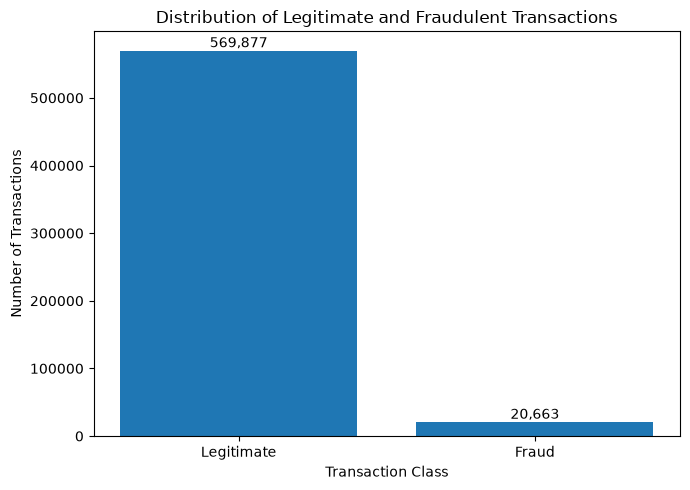

In [53]:
# Visualize class distribution

class_labels = ["Legitimate", "Fraud"]

plt.figure(figsize=(7, 5))

bars = plt.bar(
    class_labels,
    [fraud_counts[0], fraud_counts[1]]
)

plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [54]:
# Basic data quality checks

print("DATA QUALITY SUMMARY")
print("-" * 45)

print(f"Rows: {transactions.shape[0]:,}")
print(f"Columns: {transactions.shape[1]:,}")

print(f"\nDuplicate complete rows: {transactions.duplicated().sum():,}")
print(f"Duplicate TransactionIDs: {transactions['TransactionID'].duplicated().sum():,}")

total_missing = transactions.isna().sum().sum()
total_cells = transactions.shape[0] * transactions.shape[1]
missing_percentage = (total_missing / total_cells) * 100

print(f"\nTotal missing values: {total_missing:,}")
print(f"Overall missing percentage: {missing_percentage:.2f}%")

DATA QUALITY SUMMARY
---------------------------------------------
Rows: 590,540
Columns: 394

Duplicate complete rows: 0
Duplicate TransactionIDs: 0

Total missing values: 95,566,686
Overall missing percentage: 41.07%


In [55]:
# Missing-value analysis by feature

missing_summary = pd.DataFrame({
    "Missing_Count": transactions.isnull().sum(),
    "Missing_Percentage": transactions.isnull().mean() * 100
})

missing_summary = missing_summary.sort_values(
    "Missing_Percentage",
    ascending=False
)

missing_summary.head(20)

,Missing_Count,Missing_Percentage
dist2,552913,93.628374
D7,551623,93.409930
D13,528588,89.509263
D14,528353,89.469469
D12,525823,89.041047
D6,517353,87.606767
D9,515614,87.312290
D8,515614,87.312290
V153,508595,86.123717
V149,508595,86.123717


In [56]:
print("MISSING DATA SEVERITY")
print("-" * 45)

print(
    "Columns with NO missing values:",
    (missing_summary["Missing_Percentage"] == 0).sum()
)

print(
    "Columns with < 10% missing:",
    ((missing_summary["Missing_Percentage"] > 0) &
     (missing_summary["Missing_Percentage"] < 10)).sum()
)

print(
    "Columns with 10–50% missing:",
    ((missing_summary["Missing_Percentage"] >= 10) &
     (missing_summary["Missing_Percentage"] < 50)).sum()
)

print(
    "Columns with 50–80% missing:",
    ((missing_summary["Missing_Percentage"] >= 50) &
     (missing_summary["Missing_Percentage"] < 80)).sum()
)

print(
    "Columns with >= 80% missing:",
    (missing_summary["Missing_Percentage"] >= 80).sum()
)

MISSING DATA SEVERITY
---------------------------------------------
Columns with NO missing values: 20
Columns with < 10% missing: 92
Columns with 10–50% missing: 108
Columns with 50–80% missing: 119
Columns with >= 80% missing: 55


In [57]:
# Transaction amount statistics

transactions["TransactionAmt"].describe()

count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

In [58]:
# Compare transaction amounts by fraud class

amount_by_class = transactions.groupby("isFraud")["TransactionAmt"].agg(
    ["count", "mean", "median", "min", "max"]
)

amount_by_class.index = ["Legitimate", "Fraud"]

amount_by_class

,count,mean,median,min,max
Legitimate,569877,134.511665,68.5,0.251,31937.391
Fraud,20663,149.244779,75.0,0.292,5191.000


In [59]:
# Highest transaction amounts

transactions[
    ["TransactionID", "TransactionAmt", "isFraud", "ProductCD", "card4", "card6"]
].sort_values(
    "TransactionAmt",
    ascending=False
).head(10)

,TransactionID,TransactionAmt,isFraud,ProductCD,card4,card6
274339,3261339,31937.391,0,W,mastercard,credit
274336,3261336,31937.391,0,W,mastercard,credit
296021,3283021,6450.970,0,W,visa,debit
248413,3235413,6085.230,0,W,mastercard,credit
384603,3371603,5543.230,0,W,visa,credit
275535,3262535,5420.000,0,W,mastercard,debit
275529,3262529,5420.000,0,W,mastercard,debit
584767,3571767,5366.820,0,W,visa,credit
315172,3302172,5279.950,0,W,visa,credit
462514,3449514,5279.950,0,W,mastercard,credit


In [60]:
transactions["TransactionAmt"].describe()

count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

In [61]:
transactions[
    ["TransactionID", "TransactionAmt", "isFraud", "ProductCD", "card4", "card6"]
].sort_values(
    "TransactionAmt",
    ascending=False
).head(10)

,TransactionID,TransactionAmt,isFraud,ProductCD,card4,card6
274339,3261339,31937.391,0,W,mastercard,credit
274336,3261336,31937.391,0,W,mastercard,credit
296021,3283021,6450.970,0,W,visa,debit
248413,3235413,6085.230,0,W,mastercard,credit
384603,3371603,5543.230,0,W,visa,credit
275535,3262535,5420.000,0,W,mastercard,debit
275529,3262529,5420.000,0,W,mastercard,debit
584767,3571767,5366.820,0,W,visa,credit
315172,3302172,5279.950,0,W,visa,credit
462514,3449514,5279.950,0,W,mastercard,credit


In [62]:
# Calculate TransactionAmt outliers using the IQR method

Q1 = transactions["TransactionAmt"].quantile(0.25)
Q3 = transactions["TransactionAmt"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

amount_outliers = transactions[
    (transactions["TransactionAmt"] < lower_bound) |
    (transactions["TransactionAmt"] > upper_bound)
]

print("TRANSACTION AMOUNT OUTLIER ANALYSIS")
print("-" * 45)

print(f"Q1: {Q1:.3f}")
print(f"Q3: {Q3:.3f}")
print(f"IQR: {IQR:.3f}")

print(f"\nLower bound: {lower_bound:.3f}")
print(f"Upper bound: {upper_bound:.3f}")

print(f"\nNumber of outliers: {len(amount_outliers):,}")
print(
    f"Percentage of transactions identified as outliers: "
    f"{len(amount_outliers) / len(transactions) * 100:.2f}%"
)

print("\nOutliers by fraud class:")
print(amount_outliers["isFraud"].value_counts().sort_index())

TRANSACTION AMOUNT OUTLIER ANALYSIS
---------------------------------------------
Q1: 43.321
Q3: 125.000
IQR: 81.679

Lower bound: -79.198
Upper bound: 247.519

Number of outliers: 66,482
Percentage of transactions identified as outliers: 11.26%

Outliers by fraud class:
isFraud
0    63110
1     3372
Name: count, dtype: int64


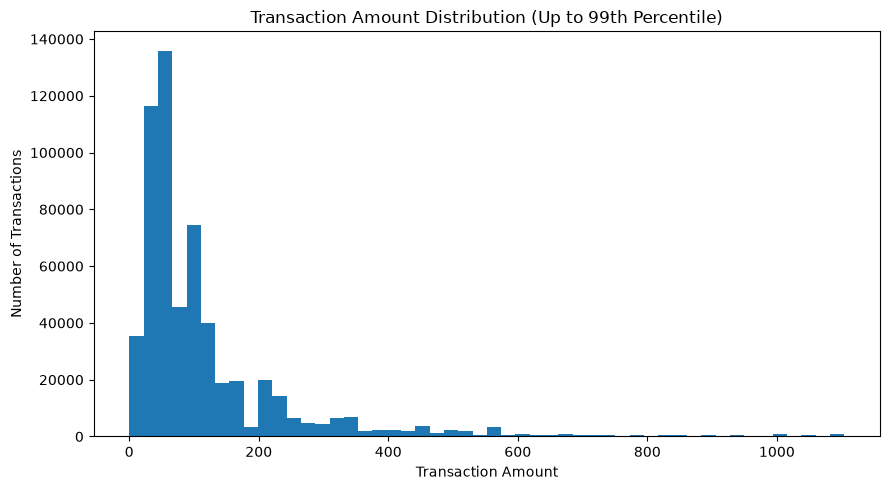

99th percentile amount: 1104.00


In [63]:
# Transaction amount distribution
# Limit visualization to the 99th percentile so extreme values
# do not squash the main distribution.

amount_99 = transactions["TransactionAmt"].quantile(0.99)

plt.figure(figsize=(9, 5))

plt.hist(
    transactions.loc[
        transactions["TransactionAmt"] <= amount_99,
        "TransactionAmt"
    ],
    bins=50
)

plt.title("Transaction Amount Distribution (Up to 99th Percentile)")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

print(f"99th percentile amount: {amount_99:.2f}")

In [64]:
# Analyze ProductCD and its relationship with fraud

product_summary = transactions.groupby("ProductCD").agg(
    Total_Transactions=("isFraud", "count"),
    Fraud_Cases=("isFraud", "sum"),
    Fraud_Rate=("isFraud", "mean")
)

product_summary["Fraud_Rate_Percent"] = (
    product_summary["Fraud_Rate"] * 100
)

product_summary = product_summary.drop(
    columns="Fraud_Rate"
).sort_values(
    "Fraud_Rate_Percent",
    ascending=False
)

product_summary

,Total_Transactions,Fraud_Cases,Fraud_Rate_Percent
ProductCD,,,
C,68519,8008,11.687269
S,11628,686,5.899553
H,33024,1574,4.766231
R,37699,1426,3.782594
W,439670,8969,2.039939


In [65]:
# Analyze card4 and its relationship with fraud

card4_summary = transactions.groupby(
    "card4",
    dropna=False
).agg(
    Total_Transactions=("isFraud", "count"),
    Fraud_Cases=("isFraud", "sum"),
    Fraud_Rate=("isFraud", "mean")
)

card4_summary["Fraud_Rate_Percent"] = (
    card4_summary["Fraud_Rate"] * 100
)

card4_summary = card4_summary.drop(
    columns="Fraud_Rate"
).sort_values(
    "Fraud_Rate_Percent",
    ascending=False
)

card4_summary

,Total_Transactions,Fraud_Cases,Fraud_Rate_Percent
card4,,,
discover,6651,514,7.728161
visa,384767,13373,3.475610
mastercard,189217,6496,3.433095
american express,8328,239,2.869837
NaN,1577,41,2.599873


In [66]:
# Analyze card6 and its relationship with fraud

card6_summary = transactions.groupby(
    "card6",
    dropna=False
).agg(
    Total_Transactions=("isFraud", "count"),
    Fraud_Cases=("isFraud", "sum"),
    Fraud_Rate=("isFraud", "mean")
)

card6_summary["Fraud_Rate_Percent"] = (
    card6_summary["Fraud_Rate"] * 100
)

card6_summary = card6_summary.drop(
    columns="Fraud_Rate"
).sort_values(
    "Fraud_Rate_Percent",
    ascending=False
)

card6_summary

,Total_Transactions,Fraud_Cases,Fraud_Rate_Percent
card6,,,
credit,148986,9950,6.678480
NaN,1571,39,2.482495
debit,439938,10674,2.426251
charge card,15,0,0.000000
debit or credit,30,0,0.000000


In [67]:
# Analyze purchaser email domains

email_summary = transactions.groupby(
    "P_emaildomain",
    dropna=False
).agg(
    Total_Transactions=("isFraud", "count"),
    Fraud_Cases=("isFraud", "sum"),
    Fraud_Rate=("isFraud", "mean")
)

email_summary["Fraud_Rate_Percent"] = (
    email_summary["Fraud_Rate"] * 100
)

email_summary = email_summary.drop(
    columns="Fraud_Rate"
)

# Keep categories with at least 1,000 transactions
email_summary_large = email_summary[
    email_summary["Total_Transactions"] >= 1000
].sort_values(
    "Fraud_Rate_Percent",
    ascending=False
)

email_summary_large.head(15)

,Total_Transactions,Fraud_Cases,Fraud_Rate_Percent
P_emaildomain,,,
outlook.com,5096,482,9.458399
hotmail.com,45250,2396,5.295028
gmail.com,228355,9943,4.354185
icloud.com,6267,197,3.143450
comcast.net,7888,246,3.118661
NaN,94456,2790,2.953756
bellsouth.net,1909,53,2.776323
live.com,3041,84,2.762249
anonymous.com,36998,859,2.321747


In [68]:
print("IDENTITY DATASET COLUMNS")
print("-" * 50)

for i, column in enumerate(identity_sample.columns, start=1):
    print(f"{i:2}. {column}")

IDENTITY DATASET COLUMNS
--------------------------------------------------
 1. TransactionID
 2. id_01
 3. id_02
 4. id_03
 5. id_04
 6. id_05
 7. id_06
 8. id_07
 9. id_08
10. id_09
11. id_10
12. id_11
13. id_12
14. id_13
15. id_14
16. id_15
17. id_16
18. id_17
19. id_18
20. id_19
21. id_20
22. id_21
23. id_22
24. id_23
25. id_24
26. id_25
27. id_26
28. id_27
29. id_28
30. id_29
31. id_30
32. id_31
33. id_32
34. id_33
35. id_34
36. id_35
37. id_36
38. id_37
39. id_38
40. DeviceType
41. DeviceInfo


In [69]:
# Load the complete identity dataset

identity = pd.read_csv(identity_path)

print("IDENTITY DATASET SUMMARY")
print("-" * 45)

print(f"Identity rows: {identity.shape[0]:,}")
print(f"Identity columns: {identity.shape[1]:,}")

print(
    f"Duplicate TransactionIDs: "
    f"{identity['TransactionID'].duplicated().sum():,}"
)

print(
    f"\nTransactions in main dataset: "
    f"{transactions.shape[0]:,}"
)

identity_coverage = (
    identity["TransactionID"].isin(
        transactions["TransactionID"]
    ).sum()
)

print(
    f"Transactions with identity records: "
    f"{identity_coverage:,}"
)

print(
    f"Identity coverage: "
    f"{identity_coverage / len(transactions) * 100:.2f}%"
)

IDENTITY DATASET SUMMARY
---------------------------------------------
Identity rows: 144,233
Identity columns: 41
Duplicate TransactionIDs: 0

Transactions in main dataset: 590,540
Transactions with identity records: 144,233
Identity coverage: 24.42%


In [70]:
# Check whether identity-record availability differs by fraud class

transactions["HasIdentity"] = transactions["TransactionID"].isin(
    identity["TransactionID"]
).astype(int)

identity_fraud_summary = transactions.groupby(
    "HasIdentity"
).agg(
    Total_Transactions=("isFraud", "count"),
    Fraud_Cases=("isFraud", "sum"),
    Fraud_Rate=("isFraud", "mean")
)

identity_fraud_summary["Fraud_Rate_Percent"] = (
    identity_fraud_summary["Fraud_Rate"] * 100
)

identity_fraud_summary = identity_fraud_summary.drop(
    columns="Fraud_Rate"
)

identity_fraud_summary.index = [
    "No Identity Record",
    "Identity Record Available"
]

identity_fraud_summary

C:\Users\Misbah\AppData\Local\Temp\ipykernel_5264\594608781.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  transactions["HasIdentity"] = transactions["TransactionID"].isin(


,Total_Transactions,Fraud_Cases,Fraud_Rate_Percent
No Identity Record,446307,9345,2.093850
Identity Record Available,144233,11318,7.847025


In [71]:
# Analyze DeviceType and its relationship with fraud

device_data = identity[
    ["TransactionID", "DeviceType"]
].merge(
    transactions[["TransactionID", "isFraud"]],
    on="TransactionID",
    how="left"
)

device_type_summary = device_data.groupby(
    "DeviceType",
    dropna=False
).agg(
    Total_Transactions=("isFraud", "count"),
    Fraud_Cases=("isFraud", "sum"),
    Fraud_Rate=("isFraud", "mean")
)

device_type_summary["Fraud_Rate_Percent"] = (
    device_type_summary["Fraud_Rate"] * 100
)

device_type_summary = device_type_summary.drop(
    columns="Fraud_Rate"
).sort_values(
    "Fraud_Rate_Percent",
    ascending=False
)

device_type_summary

,Total_Transactions,Fraud_Cases,Fraud_Rate_Percent
DeviceType,,,
mobile,55645,5657,10.166232
desktop,85165,5554,6.521458
NaN,3423,107,3.125913


In [72]:
# Explore DeviceInfo

print("DEVICE INFO SUMMARY")
print("-" * 45)

print(
    f"Unique DeviceInfo values: "
    f"{identity['DeviceInfo'].nunique():,}"
)

print(
    f"Missing DeviceInfo values: "
    f"{identity['DeviceInfo'].isna().sum():,}"
)

print(
    f"Missing percentage: "
    f"{identity['DeviceInfo'].isna().mean() * 100:.2f}%"
)

print("\nTop 15 most common DeviceInfo values:")
print(
    identity["DeviceInfo"]
    .value_counts(dropna=False)
    .head(15)
)

DEVICE INFO SUMMARY
---------------------------------------------
Unique DeviceInfo values: 1,786
Missing DeviceInfo values: 25,567
Missing percentage: 17.73%

Top 15 most common DeviceInfo values:
DeviceInfo
Windows                        47722
NaN                            25567
iOS Device                     19782
MacOS                          12573
Trident/7.0                     7440
rv:11.0                         1901
rv:57.0                          962
SM-J700M Build/MMB29K            549
SM-G610M Build/MMB29K            461
SM-G531H Build/LMY48B            410
rv:59.0                          362
SM-G935F Build/NRD90M            334
SM-G955U Build/NRD90M            328
SM-G532M Build/MMB29T            316
ALE-L23 Build/HuaweiALE-L23      312
Name: count, dtype: int64


In [73]:
# Check feature data types

dtype_summary = transactions.dtypes.value_counts()

print("TRANSACTION DATA TYPES")
print("-" * 40)

for dtype, count in dtype_summary.items():
    print(f"{str(dtype):15} : {count} columns")

numeric_cols = transactions.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_cols = transactions.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("\nTotal numeric columns:", len(numeric_cols))
print("Total categorical columns:", len(categorical_cols))

print("\nCategorical columns:")
print(categorical_cols)

TRANSACTION DATA TYPES
----------------------------------------
float64         : 376 columns
str             : 14 columns
int64           : 5 columns

Total numeric columns: 381
Total categorical columns: 14

Categorical columns:
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']


In [74]:
# Identify transaction features with very high missingness

missing_percent = (
    transactions.isna().mean() * 100
).sort_values(ascending=False)

high_missing_cols = missing_percent[
    missing_percent >= 80
]

print("COLUMNS WITH >= 80% MISSING VALUES")
print("-" * 50)

print(f"Number of columns: {len(high_missing_cols)}\n")

for column, percent in high_missing_cols.items():
    print(f"{column:10} : {percent:.2f}%")

COLUMNS WITH >= 80% MISSING VALUES
--------------------------------------------------
Number of columns: 55

dist2      : 93.63%
D7         : 93.41%
D13        : 89.51%
D14        : 89.47%
D12        : 89.04%
D6         : 87.61%
D9         : 87.31%
D8         : 87.31%
V153       : 86.12%
V149       : 86.12%
V141       : 86.12%
V146       : 86.12%
V154       : 86.12%
V162       : 86.12%
V142       : 86.12%
V158       : 86.12%
V161       : 86.12%
V157       : 86.12%
V138       : 86.12%
V139       : 86.12%
V148       : 86.12%
V140       : 86.12%
V155       : 86.12%
V156       : 86.12%
V147       : 86.12%
V163       : 86.12%
V143       : 86.12%
V145       : 86.12%
V144       : 86.12%
V165       : 86.12%
V164       : 86.12%
V152       : 86.12%
V150       : 86.12%
V151       : 86.12%
V160       : 86.12%
V159       : 86.12%
V166       : 86.12%
V329       : 86.05%
V328       : 86.05%
V326       : 86.05%
V327       : 86.05%
V325       : 86.05%
V331       : 86.05%
V330       : 86.05%
V333       

In [75]:
# Define target and basic non-feature columns

TARGET = "isFraud"
ID_COLUMN = "TransactionID"

print("TARGET / IDENTIFIER CHECK")
print("-" * 45)

print("Target:", TARGET)
print("Identifier:", ID_COLUMN)

print("\nTarget values:")
print(transactions[TARGET].value_counts())

print("\nTransactionID unique values:")
print(f"{transactions[ID_COLUMN].nunique():,}")

print("\nTotal rows:")
print(f"{len(transactions):,}")

print(
    "\nTransactionID is unique:",
    transactions[ID_COLUMN].nunique() == len(transactions)
)

TARGET / IDENTIFIER CHECK
---------------------------------------------
Target: isFraud
Identifier: TransactionID

Target values:
isFraud
0    569877
1     20663
Name: count, dtype: int64

TransactionID unique values:
590,540

Total rows:
590,540

TransactionID is unique: True


In [76]:
# Inspect the transaction time variable

print("TRANSACTION TIME SUMMARY")
print("-" * 45)

print(transactions["TransactionDT"].describe())

print("\nMissing TransactionDT:")
print(transactions["TransactionDT"].isna().sum())

print("\nFirst 5 TransactionDT values:")
print(transactions["TransactionDT"].head().tolist())

print("\nLast 5 TransactionDT values:")
print(transactions["TransactionDT"].tail().tolist())

print(
    "\nAlready sorted by TransactionDT:",
    transactions["TransactionDT"].is_monotonic_increasing
)

TRANSACTION TIME SUMMARY
---------------------------------------------
count    5.905400e+05
mean     7.372311e+06
std      4.617224e+06
min      8.640000e+04
25%      3.027058e+06
50%      7.306528e+06
75%      1.124662e+07
max      1.581113e+07
Name: TransactionDT, dtype: float64

Missing TransactionDT:
0

First 5 TransactionDT values:
[86400, 86401, 86469, 86499, 86506]

Last 5 TransactionDT values:
[15811047, 15811049, 15811079, 15811088, 15811131]

Already sorted by TransactionDT: True


In [77]:
# Create chronological 70% / 15% / 15% split

n = len(transactions)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_data = transactions.iloc[:train_end].copy()
val_data = transactions.iloc[train_end:val_end].copy()
test_data = transactions.iloc[val_end:].copy()

def split_summary(name, data):
    total = len(data)
    fraud = data["isFraud"].sum()
    fraud_rate = data["isFraud"].mean() * 100

    return {
        "Split": name,
        "Transactions": total,
        "Fraud_Cases": fraud,
        "Legitimate_Cases": total - fraud,
        "Fraud_Rate_Percent": fraud_rate,
        "Min_TransactionDT": data["TransactionDT"].min(),
        "Max_TransactionDT": data["TransactionDT"].max()
    }

split_results = pd.DataFrame([
    split_summary("Train", train_data),
    split_summary("Validation", val_data),
    split_summary("Test", test_data)
])

split_results

,Split,Transactions,Fraud_Cases,Legitimate_Cases,Fraud_Rate_Percent,Min_TransactionDT,Max_TransactionDT
0,Train,413378,14538,398840,3.516878,86400,10437996
1,Validation,88581,3042,85539,3.434145,10438003,13151840
2,Test,88581,3083,85498,3.480430,13151880,15811131


In [78]:
# Merge identity information into each chronological split

train_data = train_data.merge(
    identity,
    on="TransactionID",
    how="left"
)

val_data = val_data.merge(
    identity,
    on="TransactionID",
    how="left"
)

test_data = test_data.merge(
    identity,
    on="TransactionID",
    how="left"
)

print("AFTER IDENTITY MERGE")
print("-" * 45)

print("Train shape:", train_data.shape)
print("Validation shape:", val_data.shape)
print("Test shape:", test_data.shape)

print("\nTotal rows after merge:")
print(
    len(train_data)
    + len(val_data)
    + len(test_data)
)

print("\nOriginal total rows:")
print(len(transactions))

AFTER IDENTITY MERGE
---------------------------------------------
Train shape: (413378, 435)
Validation shape: (88581, 435)
Test shape: (88581, 435)

Total rows after merge:
590540

Original total rows:
590540


In [79]:
# Calculate feature missingness using TRAINING data only

train_missing_percent = (
    train_data.isna().mean() * 100
).sort_values(ascending=False)

high_missing_train = train_missing_percent[
    train_missing_percent >= 80
]

print("TRAINING FEATURES WITH >= 80% MISSING")
print("-" * 55)

print(
    f"Number of columns: "
    f"{len(high_missing_train)}"
)

print("\nTop 30 most-missing columns:")

for column, percent in high_missing_train.head(30).items():
    print(f"{column:12} : {percent:.2f}%")

TRAINING FEATURES WITH >= 80% MISSING
-------------------------------------------------------
Number of columns: 74

Top 30 most-missing columns:
id_24        : 99.13%
id_25        : 99.05%
id_08        : 99.05%
id_07        : 99.05%
id_26        : 99.05%
id_21        : 99.05%
id_27        : 99.05%
id_23        : 99.05%
id_22        : 99.05%
D7           : 93.53%
dist2        : 92.95%
id_18        : 91.77%
D13          : 89.34%
D14          : 89.12%
D12          : 88.56%
id_03        : 88.11%
id_04        : 88.11%
D6           : 87.28%
id_09        : 86.41%
D9           : 86.41%
D8           : 86.41%
id_10        : 86.41%
id_33        : 86.09%
id_30        : 85.05%
id_32        : 85.05%
id_34        : 85.04%
id_14        : 84.58%
V153         : 84.23%
V154         : 84.23%
V152         : 84.23%


In [80]:
# Create ML feature and target datasets

DROP_COLUMNS = (
    high_missing_train.index.tolist()
    + ["TransactionID", "isFraud"]
)

X_train = train_data.drop(
    columns=DROP_COLUMNS
)

X_val = val_data.drop(
    columns=DROP_COLUMNS
)

X_test = test_data.drop(
    columns=DROP_COLUMNS
)

y_train = train_data["isFraud"].copy()
y_val = val_data["isFraud"].copy()
y_test = test_data["isFraud"].copy()


print("ML DATASET SHAPES")
print("-" * 45)

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

print("\ny_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)

print("\nSame feature columns:")
print(
    list(X_train.columns) == list(X_val.columns)
    == list(X_test.columns)
)

print("\nRemaining missing values:")
print(f"Train: {X_train.isna().sum().sum():,}")
print(f"Validation: {X_val.isna().sum().sum():,}")
print(f"Test: {X_test.isna().sum().sum():,}")

ML DATASET SHAPES
---------------------------------------------
X_train: (413378, 359)
X_val:   (88581, 359)
X_test:  (88581, 359)

y_train: (413378,)
y_val:   (88581,)
y_test:  (88581,)

Same feature columns:
True

Remaining missing values:
Train: 53,819,049
Validation: 11,826,573
Test: 11,284,639


In [81]:
# Inspect feature types after feature removal

numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("REMAINING FEATURE TYPES")
print("-" * 45)

print(f"Numeric features:     {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Total features:       {len(X_train.columns)}")

print("\nCategorical features:")
for column in categorical_features:
    print(column)

REMAINING FEATURE TYPES
---------------------------------------------
Numeric features:     333
Categorical features: 26
Total features:       359

Categorical features:
ProductCD
card4
card6
P_emaildomain
R_emaildomain
M1
M2
M3
M4
M5
M6
M7
M8
M9
id_12
id_15
id_16
id_28
id_29
id_31
id_35
id_36
id_37
id_38
DeviceType
DeviceInfo


In [82]:
# Check categorical feature cardinality using training data only

categorical_cardinality = pd.DataFrame({
    "Feature": categorical_features,
    "Unique_Values": [
        X_train[col].nunique(dropna=True)
        for col in categorical_features
    ],
    "Missing_Percent": [
        X_train[col].isna().mean() * 100
        for col in categorical_features
    ]
})

categorical_cardinality = categorical_cardinality.sort_values(
    "Unique_Values",
    ascending=False
).reset_index(drop=True)

categorical_cardinality

,Feature,Unique_Values,Missing_Percent
0,DeviceInfo,1546,77.898679
1,id_31,108,74.058610
2,R_emaildomain,60,75.073419
3,P_emaildomain,59,15.553803
4,ProductCD,5,0.000000
5,card4,4,0.200543
6,card6,4,0.199817
7,id_15,3,73.984102
8,M4,3,48.417429
9,M1,2,53.804266


In [83]:
# Inspect important numeric-coded features

numeric_coded_features = [
    "card1",
    "card2",
    "card3",
    "card5",
    "addr1",
    "addr2"
]

numeric_coded_summary = pd.DataFrame({
    "Feature": numeric_coded_features,
    "Unique_Values": [
        X_train[col].nunique(dropna=True)
        for col in numeric_coded_features
    ],
    "Missing_Percent": [
        X_train[col].isna().mean() * 100
        for col in numeric_coded_features
    ],
    "Min": [
        X_train[col].min()
        for col in numeric_coded_features
    ],
    "Max": [
        X_train[col].max()
        for col in numeric_coded_features
    ]
})

numeric_coded_summary

,Feature,Unique_Values,Missing_Percent,Min,Max
0,card1,12242,0.000000,1000.0,18396.0
1,card2,500,1.577249,100.0,600.0
2,card3,105,0.198608,100.0,231.0
3,card5,110,0.718229,100.0,237.0
4,addr1,318,11.495048,100.0,540.0
5,addr2,67,11.495048,10.0,102.0


In [84]:
# Convert raw DeviceInfo into broader device families

def create_device_family(value):
    if pd.isna(value):
        return "Missing"

    value = str(value).lower()

    if "windows" in value:
        return "Windows"

    elif "ios" in value or "iphone" in value or "ipad" in value:
        return "iOS"

    elif "macos" in value or "mac os" in value:
        return "MacOS"

    elif (
        "samsung" in value
        or "sm-" in value
        or "android" in value
    ):
        return "Android/Samsung"

    elif "huawei" in value or "ale-" in value:
        return "Huawei"

    elif "rv:" in value or "trident" in value:
        return "Browser/Other"

    else:
        return "Other"


for dataset in [X_train, X_val, X_test]:

    dataset["DeviceFamily"] = (
        dataset["DeviceInfo"]
        .apply(create_device_family)
    )

    dataset.drop(
        columns=["DeviceInfo"],
        inplace=True
    )


print("TRAINING DEVICE FAMILY")
print("-" * 40)

print(
    X_train["DeviceFamily"]
    .value_counts(dropna=False)
)

print("\nNumber of features:", X_train.shape[1])

TRAINING DEVICE FAMILY
----------------------------------------
DeviceFamily
Missing            322016
Windows             36708
iOS                 16085
MacOS               10191
Browser/Other        9602
Other                8618
Android/Samsung      8573
Huawei               1585
Name: count, dtype: int64

Number of features: 359


In [85]:
# Treat anonymized numeric codes as categorical features

coded_categorical_features = [
    "card1",
    "card2",
    "card3",
    "card5",
    "addr1",
    "addr2"
]

for dataset in [X_train, X_val, X_test]:

    for column in coded_categorical_features:

        dataset[column] = (
            dataset[column]
            .astype("string")
        )


# Recalculate feature groups after transformation

numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()


print("UPDATED FEATURE TYPES")
print("-" * 45)

print(f"Numeric features:     {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Total features:       {len(X_train.columns)}")

print("\nCoded fields now categorical:")

for column in coded_categorical_features:
    print(
        f"{column:6} -> {X_train[column].dtype}"
    )

print(
    "\nDeviceFamily categories:",
    X_train["DeviceFamily"].nunique()
)

UPDATED FEATURE TYPES
---------------------------------------------
Numeric features:     327
Categorical features: 32
Total features:       359

Coded fields now categorical:
card1  -> string
card2  -> string
card3  -> string
card5  -> string
addr1  -> string
addr2  -> string

DeviceFamily categories: 8


In [86]:
# Recheck categorical cardinality after feature engineering

categorical_cardinality_updated = pd.DataFrame({
    "Feature": categorical_features,
    "Unique_Values": [
        X_train[col].nunique(dropna=True)
        for col in categorical_features
    ],
    "Missing_Percent": [
        X_train[col].isna().mean() * 100
        for col in categorical_features
    ]
})

categorical_cardinality_updated = (
    categorical_cardinality_updated
    .sort_values(
        "Unique_Values",
        ascending=False
    )
    .reset_index(drop=True)
)

categorical_cardinality_updated

,Feature,Unique_Values,Missing_Percent
0,card1,12242,0.000000
1,card2,500,1.577249
2,addr1,318,11.495048
3,card5,110,0.718229
4,id_31,108,74.058610
5,card3,105,0.198608
6,addr2,67,11.495048
7,R_emaildomain,60,75.073419
8,P_emaildomain,59,15.553803
9,DeviceFamily,8,0.000000


In [87]:
# Separate categorical features by cardinality

LOW_CARDINALITY_LIMIT = 10

low_cardinality_features = [
    col for col in categorical_features
    if X_train[col].nunique(dropna=True)
    <= LOW_CARDINALITY_LIMIT
]

high_cardinality_features = [
    col for col in categorical_features
    if X_train[col].nunique(dropna=True)
    > LOW_CARDINALITY_LIMIT
]

print("CATEGORICAL FEATURE GROUPS")
print("-" * 50)

print(
    f"Low-cardinality features: "
    f"{len(low_cardinality_features)}"
)

for col in low_cardinality_features:
    print(
        f"  {col:20} "
        f"{X_train[col].nunique(dropna=True)} categories"
    )

print(
    f"\nHigh-cardinality features: "
    f"{len(high_cardinality_features)}"
)

for col in high_cardinality_features:
    print(
        f"  {col:20} "
        f"{X_train[col].nunique(dropna=True)} categories"
    )

CATEGORICAL FEATURE GROUPS
--------------------------------------------------
Low-cardinality features: 23
  ProductCD            5 categories
  card4                4 categories
  card6                4 categories
  M1                   2 categories
  M2                   2 categories
  M3                   2 categories
  M4                   3 categories
  M5                   2 categories
  M6                   2 categories
  M7                   2 categories
  M8                   2 categories
  M9                   2 categories
  id_12                2 categories
  id_15                3 categories
  id_16                2 categories
  id_28                2 categories
  id_29                2 categories
  id_35                2 categories
  id_36                2 categories
  id_37                2 categories
  id_38                2 categories
  DeviceType           2 categories
  DeviceFamily         8 categories

High-cardinality features: 9
  card1                12242 catego

In [88]:
# Frequency encode high-cardinality categorical features
# Mappings are learned ONLY from training data

frequency_maps = {}

for column in high_cardinality_features:

    # Learn frequencies from training data
    freq_map = (
        X_train[column]
        .fillna("Missing")
        .value_counts(normalize=True)
        .to_dict()
    )

    frequency_maps[column] = freq_map

    # Apply the training mapping to all datasets
    for dataset in [X_train, X_val, X_test]:

        dataset[column + "_Freq"] = (
            dataset[column]
            .fillna("Missing")
            .map(freq_map)
            .fillna(0)
            .astype(float)
        )

        dataset.drop(
            columns=[column],
            inplace=True
        )


# Recalculate feature groups

numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()


print("AFTER FREQUENCY ENCODING")
print("-" * 50)

print(f"Numeric features:     {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Total features:       {X_train.shape[1]}")

print("\nCreated frequency features:")

for column in high_cardinality_features:
    print(f"  {column}_Freq")

print("\nDataset shapes:")
print("Train:     ", X_train.shape)
print("Validation:", X_val.shape)
print("Test:      ", X_test.shape)

print("\nFeature columns identical:")
print(
    list(X_train.columns)
    == list(X_val.columns)
    == list(X_test.columns)
)

AFTER FREQUENCY ENCODING
--------------------------------------------------
Numeric features:     336
Categorical features: 23
Total features:       359

Created frequency features:
  card1_Freq
  card2_Freq
  card3_Freq
  card5_Freq
  addr1_Freq
  addr2_Freq
  P_emaildomain_Freq
  R_emaildomain_Freq
  id_31_Freq

Dataset shapes:
Train:      (413378, 359)
Validation: (88581, 359)
Test:       (88581, 359)

Feature columns identical:
True


In [89]:
# Build preprocessing pipeline for Model 1

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Numeric preprocessing
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# Categorical preprocessing
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Missing"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


# Combine both pipelines
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)


print("PREPROCESSOR READY")
print("-" * 45)

print(
    f"Numeric features: "
    f"{len(numeric_features)}"
)

print(
    f"Categorical features: "
    f"{len(categorical_features)}"
)

print(
    f"Raw input features: "
    f"{X_train.shape[1]}"
)

print("\nNo model has been trained yet.")

PREPROCESSOR READY
---------------------------------------------
Numeric features: 336
Categorical features: 23
Raw input features: 359

No model has been trained yet.


In [90]:
# Model 1 — Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                solver="liblinear",
                random_state=42
            )
        )
    ]
)

print("LOGISTIC REGRESSION PIPELINE READY")
print("-" * 45)

print("Training rows:", X_train.shape[0])
print("Input features:", X_train.shape[1])
print("Fraud cases:", y_train.sum())
print("Legitimate cases:", (y_train == 0).sum())

print("\nModel has been created but NOT trained yet.")

LOGISTIC REGRESSION PIPELINE READY
---------------------------------------------
Training rows: 413378
Input features: 359
Fraud cases: 14538
Legitimate cases: 398840

Model has been created but NOT trained yet.


In [91]:
# Rebuild Logistic Regression with a solver suited to large datasets

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                solver="saga",
                max_iter=300,
                tol=1e-3,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Faster Logistic Regression pipeline ready.")

Faster Logistic Regression pipeline ready.


In [92]:
# Train the faster Logistic Regression baseline

import time

print("TRAINING LOGISTIC REGRESSION")
print("-" * 45)

start_time = time.time()

logistic_model.fit(
    X_train,
    y_train
)

training_time = time.time() - start_time

print("\nTRAINING COMPLETE")
print("-" * 45)
print(f"Training time: {training_time / 60:.2f} minutes")

TRAINING LOGISTIC REGRESSION
---------------------------------------------


c:\Users\Misbah\miniconda3\envs\fraudguard\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



TRAINING COMPLETE
---------------------------------------------
Training time: 16.65 minutes


c:\Users\Misbah\miniconda3\envs\fraudguard\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [93]:
# Evaluate Model 1 on the validation set

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# Fraud probabilities
val_probabilities = logistic_model.predict_proba(X_val)[:, 1]

# Default classification threshold = 0.50
val_predictions = (
    val_probabilities >= 0.50
).astype(int)


# Calculate metrics
accuracy = accuracy_score(
    y_val,
    val_predictions
)

precision = precision_score(
    y_val,
    val_predictions
)

recall = recall_score(
    y_val,
    val_predictions
)

f1 = f1_score(
    y_val,
    val_predictions
)

roc_auc = roc_auc_score(
    y_val,
    val_probabilities
)

pr_auc = average_precision_score(
    y_val,
    val_probabilities
)

cm = confusion_matrix(
    y_val,
    val_predictions
)


print("LOGISTIC REGRESSION — VALIDATION RESULTS")
print("-" * 50)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"PR-AUC:    {pr_auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

LOGISTIC REGRESSION — VALIDATION RESULTS
--------------------------------------------------
Accuracy:  0.7352
Precision: 0.0934
Recall:    0.7702
F1 Score:  0.1665
ROC-AUC:   0.8394
PR-AUC:    0.3709

Confusion Matrix:
[[62785 22754]
 [  699  2343]]


In [94]:
# Compare different fraud probability thresholds

import pandas as pd
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

thresholds = [
    0.20, 0.25, 0.30, 0.35,
    0.40, 0.45, 0.50, 0.55,
    0.60, 0.65, 0.70, 0.75,
    0.80
]

results = []

for threshold in thresholds:

    predictions = (
        val_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        predictions
    ).ravel()

    results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val, predictions
        ),
        "Recall": recall_score(
            y_val, predictions
        ),
        "F1": f1_score(
            y_val, predictions
        ),
        "False_Positives": fp,
        "False_Negatives": fn,
        "True_Positives": tp
    })


threshold_results = pd.DataFrame(results)

threshold_results.round(4)

,Threshold,Precision,Recall,F1,False_Positives,False_Negatives,True_Positives
0,0.20,0.0462,0.9543,0.0881,59976,139,2903
1,0.25,0.0508,0.9339,0.0963,53114,201,2841
2,0.30,0.0562,0.9142,0.1058,46733,261,2781
3,0.35,0.0623,0.8826,0.1164,40397,357,2685
4,0.40,0.0703,0.8471,0.1298,34089,465,2577
5,0.45,0.0807,0.8110,0.1469,28086,575,2467
6,0.50,0.0934,0.7702,0.1665,22754,699,2343
7,0.55,0.1098,0.7357,0.1911,18148,804,2238
8,0.60,0.1276,0.6828,0.2151,14196,965,2077
9,0.65,0.1523,0.6384,0.2460,10807,1100,1942


In [95]:
# Find best Logistic Regression threshold automatically

import numpy as np
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, thresholds_curve = (
    precision_recall_curve(
        y_val,
        val_probabilities
    )
)

# The last precision/recall values have no matching threshold
precision_t = precision_curve[:-1]
recall_t = recall_curve[:-1]

f1_curve = (
    2 * precision_t * recall_t
    / (precision_t + recall_t + 1e-10)
)

best_index = np.argmax(f1_curve)

best_lr_threshold = thresholds_curve[best_index]

print("BEST LOGISTIC REGRESSION VALIDATION THRESHOLD")
print("-" * 55)

print(f"Threshold: {best_lr_threshold:.4f}")
print(f"Precision: {precision_t[best_index]:.4f}")
print(f"Recall:    {recall_t[best_index]:.4f}")
print(f"F1 Score:  {f1_curve[best_index]:.4f}")

BEST LOGISTIC REGRESSION VALIDATION THRESHOLD
-------------------------------------------------------
Threshold: 0.9096
Precision: 0.4781
Recall:    0.3304
F1 Score:  0.3907


In [96]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

scale_pos_weight = (
    (y_train == 0).sum()
    / (y_train == 1).sum()
)

print(
    "Training scale_pos_weight:",
    round(scale_pos_weight, 2)
)

print("Training rows:", len(y_train))
print("Fraud cases:", int((y_train == 1).sum()))
print("Legitimate cases:", int((y_train == 0).sum()))

XGBoost version: 3.4.1
Training scale_pos_weight: 27.43
Training rows: 413378
Fraud cases: 14538
Legitimate cases: 398840


In [97]:
# XGBoost-specific preprocessing
# Numeric features pass through unchanged.
# Low-cardinality categorical features are one-hot encoded.

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder


xgb_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Missing"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


xgb_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            "passthrough",
            numeric_features
        ),
        (
            "categorical",
            xgb_categorical_pipeline,
            categorical_features
        )
    ]
)


print("XGBOOST PREPROCESSOR READY")
print("-" * 45)

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Raw input features:", X_train.shape[1])

print("\nNumeric NaN values will be left for XGBoost to handle.")
print("No model has been trained yet.")

XGBOOST PREPROCESSOR READY
---------------------------------------------
Numeric features: 336
Categorical features: 23
Raw input features: 359

Numeric NaN values will be left for XGBoost to handle.
No model has been trained yet.


In [98]:
# Model 2 — XGBoost

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline


xgb_classifier = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,

    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="binary:logistic",
    eval_metric="aucpr",

    scale_pos_weight=scale_pos_weight,

    tree_method="hist",

    random_state=42,
    n_jobs=-1
)


xgb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            xgb_preprocessor
        ),
        (
            "classifier",
            xgb_classifier
        )
    ]
)


print("XGBOOST MODEL READY")
print("-" * 45)

print("Trees:", xgb_classifier.n_estimators)
print("Learning rate:", xgb_classifier.learning_rate)
print("Max depth:", xgb_classifier.max_depth)

print(
    "Scale pos weight:",
    round(scale_pos_weight, 2)
)

print("\nModel has been created but NOT trained yet.")

XGBOOST MODEL READY
---------------------------------------------
Trees: 500
Learning rate: 0.05
Max depth: 6
Scale pos weight: 27.43

Model has been created but NOT trained yet.


In [99]:
# Train Model 2 — XGBoost

import time

print("TRAINING XGBOOST")
print("-" * 45)

start_time = time.time()

xgb_model.fit(
    X_train,
    y_train
)

xgb_training_time = time.time() - start_time

print("\nXGBOOST TRAINING COMPLETE")
print("-" * 45)

print(
    f"Training time: "
    f"{xgb_training_time / 60:.2f} minutes"
)

TRAINING XGBOOST
---------------------------------------------

XGBOOST TRAINING COMPLETE
---------------------------------------------
Training time: 2.22 minutes


In [100]:
# Evaluate XGBoost on validation data

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Fraud probabilities
xgb_val_probabilities = xgb_model.predict_proba(X_val)[:, 1]

# Default threshold = 0.50
xgb_val_predictions = (
    xgb_val_probabilities >= 0.50
).astype(int)


# Calculate metrics
xgb_accuracy = accuracy_score(
    y_val,
    xgb_val_predictions
)

xgb_precision = precision_score(
    y_val,
    xgb_val_predictions
)

xgb_recall = recall_score(
    y_val,
    xgb_val_predictions
)

xgb_f1 = f1_score(
    y_val,
    xgb_val_predictions
)

xgb_roc_auc = roc_auc_score(
    y_val,
    xgb_val_probabilities
)

xgb_pr_auc = average_precision_score(
    y_val,
    xgb_val_probabilities
)


print("XGBOOST — VALIDATION RESULTS")
print("-" * 45)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")
print(f"PR-AUC   : {xgb_pr_auc:.4f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_val,
        xgb_val_predictions
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        xgb_val_predictions,
        digits=4
    )
)

XGBOOST — VALIDATION RESULTS
---------------------------------------------
Accuracy : 0.9455
Precision: 0.3436
Recall   : 0.6463
F1 Score : 0.4487
ROC-AUC  : 0.9155
PR-AUC   : 0.5433

Confusion Matrix:
[[81783  3756]
 [ 1076  1966]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9870    0.9561    0.9713     85539
           1     0.3436    0.6463    0.4487      3042

    accuracy                         0.9455     88581
   macro avg     0.6653    0.8012    0.7100     88581
weighted avg     0.9649    0.9455    0.9534     88581



In [101]:
# Find the XGBoost threshold that maximizes F1
# using VALIDATION data only

from sklearn.metrics import precision_recall_curve
import numpy as np

xgb_precision_curve, xgb_recall_curve, xgb_thresholds_curve = (
    precision_recall_curve(
        y_val,
        xgb_val_probabilities
    )
)

# Last precision/recall values do not have a corresponding threshold
xgb_precision_t = xgb_precision_curve[:-1]
xgb_recall_t = xgb_recall_curve[:-1]

xgb_f1_curve = (
    2
    * xgb_precision_t
    * xgb_recall_t
    / (
        xgb_precision_t
        + xgb_recall_t
        + 1e-10
    )
)

xgb_best_index = np.argmax(xgb_f1_curve)

best_xgb_threshold = (
    xgb_thresholds_curve[xgb_best_index]
)

best_xgb_precision = (
    xgb_precision_t[xgb_best_index]
)

best_xgb_recall = (
    xgb_recall_t[xgb_best_index]
)

best_xgb_f1 = (
    xgb_f1_curve[xgb_best_index]
)


print("XGBOOST — BEST VALIDATION F1 THRESHOLD")
print("-" * 50)

print(
    f"Threshold : {best_xgb_threshold:.4f}"
)

print(
    f"Precision : {best_xgb_precision:.4f}"
)

print(
    f"Recall    : {best_xgb_recall:.4f}"
)

print(
    f"F1 Score  : {best_xgb_f1:.4f}"
)

XGBOOST — BEST VALIDATION F1 THRESHOLD
--------------------------------------------------
Threshold : 0.7271
Precision : 0.5883
Recall    : 0.4579
F1 Score  : 0.5150


In [102]:
# XGBoost validation performance at the selected threshold

xgb_tuned_predictions = (
    xgb_val_probabilities >= best_xgb_threshold
).astype(int)

xgb_tuned_cm = confusion_matrix(
    y_val,
    xgb_tuned_predictions
)

tn, fp, fn, tp = xgb_tuned_cm.ravel()

print("XGBOOST — TUNED VALIDATION RESULTS")
print("-" * 50)

print(f"Selected threshold : {best_xgb_threshold:.4f}")
print(f"True Negatives     : {tn:,}")
print(f"False Positives    : {fp:,}")
print(f"False Negatives    : {fn:,}")
print(f"True Positives     : {tp:,}")

print("\nPrecision :", f"{precision_score(y_val, xgb_tuned_predictions):.4f}")
print("Recall    :", f"{recall_score(y_val, xgb_tuned_predictions):.4f}")
print("F1 Score  :", f"{f1_score(y_val, xgb_tuned_predictions):.4f}")

print("\nConfusion Matrix:")
print(xgb_tuned_cm)

XGBOOST — TUNED VALIDATION RESULTS
--------------------------------------------------
Selected threshold : 0.7271
True Negatives     : 84,564
False Positives    : 975
False Negatives    : 1,649
True Positives     : 1,393

Precision : 0.5883
Recall    : 0.4579
F1 Score  : 0.5150

Confusion Matrix:
[[84564   975]
 [ 1649  1393]]


In [103]:
# Model 2B — Tuned XGBoost candidate
# Model 2A remains untouched.

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgb_classifier_2b = XGBClassifier(
    n_estimators=700,
    learning_rate=0.03,

    max_depth=5,
    min_child_weight=3,

    subsample=0.85,
    colsample_bytree=0.85,

    reg_alpha=0.1,
    reg_lambda=2.0,

    objective="binary:logistic",
    eval_metric="aucpr",

    scale_pos_weight=scale_pos_weight,

    tree_method="hist",

    random_state=42,
    n_jobs=-1
)


xgb_model_2b = Pipeline(
    steps=[
        ("preprocessor", xgb_preprocessor),
        ("classifier", xgb_classifier_2b)
    ]
)


print("XGBOOST MODEL 2B READY")
print("-" * 45)

print("Trees:", xgb_classifier_2b.n_estimators)
print("Learning rate:", xgb_classifier_2b.learning_rate)
print("Max depth:", xgb_classifier_2b.max_depth)
print("Min child weight:", xgb_classifier_2b.min_child_weight)
print("Subsample:", xgb_classifier_2b.subsample)
print("Column sample:", xgb_classifier_2b.colsample_bytree)
print("L1 regularization:", xgb_classifier_2b.reg_alpha)
print("L2 regularization:", xgb_classifier_2b.reg_lambda)

print("\nModel 2A has NOT been overwritten.")
print("Model 2B has NOT been trained yet.")

XGBOOST MODEL 2B READY
---------------------------------------------
Trees: 700
Learning rate: 0.03
Max depth: 5
Min child weight: 3
Subsample: 0.85
Column sample: 0.85
L1 regularization: 0.1
L2 regularization: 2.0

Model 2A has NOT been overwritten.
Model 2B has NOT been trained yet.


In [104]:
# Train XGBoost Model 2B

import time

print("TRAINING XGBOOST MODEL 2B")
print("-" * 45)

start_time = time.time()

xgb_model_2b.fit(
    X_train,
    y_train
)

xgb_2b_training_time = time.time() - start_time

print("\nXGBOOST MODEL 2B TRAINING COMPLETE")
print("-" * 45)

print(
    f"Training time: "
    f"{xgb_2b_training_time / 60:.2f} minutes"
)

TRAINING XGBOOST MODEL 2B
---------------------------------------------

XGBOOST MODEL 2B TRAINING COMPLETE
---------------------------------------------
Training time: 2.56 minutes


In [105]:
# Evaluate XGBoost Model 2B on validation data

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve
)

import numpy as np


# -----------------------------------------
# 1. Validation probabilities
# -----------------------------------------

xgb_2b_val_probabilities = (
    xgb_model_2b.predict_proba(X_val)[:, 1]
)


# -----------------------------------------
# 2. Default threshold = 0.50
# -----------------------------------------

xgb_2b_predictions = (
    xgb_2b_val_probabilities >= 0.50
).astype(int)


xgb_2b_accuracy = accuracy_score(
    y_val,
    xgb_2b_predictions
)

xgb_2b_precision = precision_score(
    y_val,
    xgb_2b_predictions
)

xgb_2b_recall = recall_score(
    y_val,
    xgb_2b_predictions
)

xgb_2b_f1 = f1_score(
    y_val,
    xgb_2b_predictions
)

xgb_2b_roc_auc = roc_auc_score(
    y_val,
    xgb_2b_val_probabilities
)

xgb_2b_pr_auc = average_precision_score(
    y_val,
    xgb_2b_val_probabilities
)


print("MODEL 2B — DEFAULT THRESHOLD 0.50")
print("-" * 50)

print(f"Accuracy : {xgb_2b_accuracy:.4f}")
print(f"Precision: {xgb_2b_precision:.4f}")
print(f"Recall   : {xgb_2b_recall:.4f}")
print(f"F1 Score : {xgb_2b_f1:.4f}")
print(f"ROC-AUC  : {xgb_2b_roc_auc:.4f}")
print(f"PR-AUC   : {xgb_2b_pr_auc:.4f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_val,
        xgb_2b_predictions
    )
)


# -----------------------------------------
# 3. Find best validation F1 threshold
# -----------------------------------------

precision_curve_2b, recall_curve_2b, thresholds_curve_2b = (
    precision_recall_curve(
        y_val,
        xgb_2b_val_probabilities
    )
)

precision_t_2b = precision_curve_2b[:-1]
recall_t_2b = recall_curve_2b[:-1]

f1_curve_2b = (
    2
    * precision_t_2b
    * recall_t_2b
    / (
        precision_t_2b
        + recall_t_2b
        + 1e-10
    )
)

best_index_2b = np.argmax(f1_curve_2b)

best_xgb_2b_threshold = (
    thresholds_curve_2b[best_index_2b]
)

best_xgb_2b_precision = (
    precision_t_2b[best_index_2b]
)

best_xgb_2b_recall = (
    recall_t_2b[best_index_2b]
)

best_xgb_2b_f1 = (
    f1_curve_2b[best_index_2b]
)


print("\nMODEL 2B — BEST VALIDATION F1 THRESHOLD")
print("-" * 50)

print(f"Threshold : {best_xgb_2b_threshold:.4f}")
print(f"Precision : {best_xgb_2b_precision:.4f}")
print(f"Recall    : {best_xgb_2b_recall:.4f}")
print(f"F1 Score  : {best_xgb_2b_f1:.4f}")

MODEL 2B — DEFAULT THRESHOLD 0.50
--------------------------------------------------
Accuracy : 0.9125
Precision: 0.2375
Recall   : 0.7002
F1 Score : 0.3546
ROC-AUC  : 0.9071
PR-AUC   : 0.5193

Confusion Matrix:
[[78699  6840]
 [  912  2130]]

MODEL 2B — BEST VALIDATION F1 THRESHOLD
--------------------------------------------------
Threshold : 0.7856
Precision : 0.5532
Recall    : 0.4648
F1 Score  : 0.5052


In [106]:
# -------------------------------------------------
# FINAL MODEL SELECTION AFTER VALIDATION
# -------------------------------------------------

final_model = xgb_model
final_threshold = best_xgb_threshold

print("FINAL MODEL SELECTED")
print("-" * 50)

print("Model       : XGBoost Model 2A")
print(f"Threshold   : {final_threshold:.4f}")

print("\nValidation Performance")
print(f"ROC-AUC     : {xgb_roc_auc:.4f}")
print(f"PR-AUC      : {xgb_pr_auc:.4f}")
print(f"Precision   : {best_xgb_precision:.4f}")
print(f"Recall      : {best_xgb_recall:.4f}")
print(f"F1 Score    : {best_xgb_f1:.4f}")

print("\nTest set has NOT been used for model selection.")

FINAL MODEL SELECTED
--------------------------------------------------
Model       : XGBoost Model 2A
Threshold   : 0.7271

Validation Performance
ROC-AUC     : 0.9155
PR-AUC      : 0.5433
Precision   : 0.5883
Recall      : 0.4579
F1 Score    : 0.5150

Test set has NOT been used for model selection.


In [107]:
# =================================================
# FINAL EVALUATION — UNTOUCHED TEST SET
# =================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)


# 1. Generate fraud probabilities
test_probabilities = (
    final_model.predict_proba(X_test)[:, 1]
)


# 2. Apply LOCKED validation-selected threshold
test_predictions = (
    test_probabilities >= final_threshold
).astype(int)


# 3. Calculate final test metrics
test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

test_precision = precision_score(
    y_test,
    test_predictions
)

test_recall = recall_score(
    y_test,
    test_predictions
)

test_f1 = f1_score(
    y_test,
    test_predictions
)

test_roc_auc = roc_auc_score(
    y_test,
    test_probabilities
)

test_pr_auc = average_precision_score(
    y_test,
    test_probabilities
)


# 4. Confusion matrix
test_cm = confusion_matrix(
    y_test,
    test_predictions
)

tn_test, fp_test, fn_test, tp_test = (
    test_cm.ravel()
)


# 5. Display final results
print("FINAL XGBOOST — UNTOUCHED TEST RESULTS")
print("=" * 55)

print(f"Locked threshold : {final_threshold:.4f}")

print("\nPerformance Metrics")
print("-" * 55)

print(f"Accuracy  : {test_accuracy:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1 Score  : {test_f1:.4f}")
print(f"ROC-AUC   : {test_roc_auc:.4f}")
print(f"PR-AUC    : {test_pr_auc:.4f}")


print("\nConfusion Matrix")
print("-" * 55)

print(f"True Negatives  : {tn_test:,}")
print(f"False Positives : {fp_test:,}")
print(f"False Negatives : {fn_test:,}")
print(f"True Positives  : {tp_test:,}")

print("\nMatrix:")
print(test_cm)


print("\nClassification Report")
print("-" * 55)

print(
    classification_report(
        y_test,
        test_predictions,
        digits=4
    )
)

FINAL XGBOOST — UNTOUCHED TEST RESULTS
Locked threshold : 0.7271

Performance Metrics
-------------------------------------------------------
Accuracy  : 0.9655
Precision : 0.5056
Recall    : 0.4535
F1 Score  : 0.4781
ROC-AUC   : 0.8993
PR-AUC    : 0.5028

Confusion Matrix
-------------------------------------------------------
True Negatives  : 84,131
False Positives : 1,367
False Negatives : 1,685
True Positives  : 1,398

Matrix:
[[84131  1367]
 [ 1685  1398]]

Classification Report
-------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9804    0.9840    0.9822     85498
           1     0.5056    0.4535    0.4781      3083

    accuracy                         0.9655     88581
   macro avg     0.7430    0.7187    0.7301     88581
weighted avg     0.9638    0.9655    0.9646     88581



In [108]:
# Find thresholds for high fraud recall
# VALIDATION DATA ONLY

from sklearn.metrics import precision_recall_curve
import numpy as np

precision_curve, recall_curve, thresholds_curve = (
    precision_recall_curve(
        y_val,
        xgb_val_probabilities
    )
)

targets = [0.90, 0.95, 0.99]

print("HIGH-RECALL THRESHOLD OPTIONS")
print("=" * 70)

for target in targets:

    valid_indices = np.where(
        recall_curve[:-1] >= target
    )[0]

    if len(valid_indices) > 0:

        # Among thresholds satisfying target recall,
        # select the one with highest precision
        best_idx = valid_indices[
            np.argmax(
                precision_curve[:-1][valid_indices]
            )
        ]

        threshold = thresholds_curve[best_idx]

        predictions = (
            xgb_val_probabilities >= threshold
        ).astype(int)

        cm = confusion_matrix(
            y_val,
            predictions
        )

        tn, fp, fn, tp = cm.ravel()

        print(f"\nTarget Recall: {target:.0%}")
        print(f"Threshold    : {threshold:.4f}")
        print(f"Precision    : {precision_score(y_val, predictions):.4f}")
        print(f"Recall       : {recall_score(y_val, predictions):.4f}")
        print(f"Fraud caught : {tp:,} / {tp + fn:,}")
        print(f"Fraud missed : {fn:,}")
        print(f"False alerts : {fp:,}")

HIGH-RECALL THRESHOLD OPTIONS

Target Recall: 90%
Threshold    : 0.1679
Precision    : 0.1077
Recall       : 0.9001
Fraud caught : 2,738 / 3,042
Fraud missed : 304
False alerts : 22,688

Target Recall: 95%
Threshold    : 0.1061
Precision    : 0.0740
Recall       : 0.9500
Fraud caught : 2,890 / 3,042
Fraud missed : 152
False alerts : 36,144

Target Recall: 99%
Threshold    : 0.0362
Precision    : 0.0437
Recall       : 0.9901
Fraud caught : 3,012 / 3,042
Fraud missed : 30
False alerts : 65,860


In [109]:
# =================================================
# SAVE FINAL FRAUDGUARD MODEL ARTIFACTS
# =================================================

import joblib
import json
from pathlib import Path


models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)


# Save complete pipeline:
# preprocessing + XGBoost classifier
joblib.dump(
    final_model,
    models_dir / "fraudguard_xgboost_pipeline.joblib"
)


# Save important deployment information
model_config = {
    "model_name": "XGBoost Model 2A",
    "threshold": float(final_threshold),

    "validation": {
        "roc_auc": float(xgb_roc_auc),
        "pr_auc": float(xgb_pr_auc),
        "precision": float(best_xgb_precision),
        "recall": float(best_xgb_recall),
        "f1": float(best_xgb_f1)
    },

    "test": {
        "accuracy": float(test_accuracy),
        "roc_auc": float(test_roc_auc),
        "pr_auc": float(test_pr_auc),
        "precision": float(test_precision),
        "recall": float(test_recall),
        "f1": float(test_f1),

        "true_negatives": int(tn_test),
        "false_positives": int(fp_test),
        "false_negatives": int(fn_test),
        "true_positives": int(tp_test)
    }
}


with open(
    models_dir / "fraudguard_model_config.json",
    "w"
) as file:
    json.dump(
        model_config,
        file,
        indent=4
    )


print("FRAUDGUARD MODEL SAVED")
print("-" * 50)

print(
    "Pipeline:",
    models_dir / "fraudguard_xgboost_pipeline.joblib"
)

print(
    "Configuration:",
    models_dir / "fraudguard_model_config.json"
)

print(f"\nLocked threshold: {final_threshold:.4f}")

FRAUDGUARD MODEL SAVED
--------------------------------------------------
Pipeline: ..\models\fraudguard_xgboost_pipeline.joblib
Configuration: ..\models\fraudguard_model_config.json

Locked threshold: 0.7271


In [110]:
# =================================================
# SHAP EXPLAINABILITY — STEP 1
# Extract trained preprocessing and XGBoost model
# =================================================

import shap

trained_preprocessor = final_model.named_steps["preprocessor"]
trained_xgb = final_model.named_steps["classifier"]

print("SHAP version:", shap.__version__)
print("Classifier type:", type(trained_xgb).__name__)
print("Preprocessor type:", type(trained_preprocessor).__name__)

print("\nSHAP COMPONENTS READY")

SHAP version: 0.52.0
Classifier type: XGBClassifier
Preprocessor type: ColumnTransformer

SHAP COMPONENTS READY


In [111]:
# =================================================
# SHAP EXPLAINABILITY — STEP 2
# Get the exact feature names seen by XGBoost
# =================================================

shap_feature_names = (
    trained_preprocessor.get_feature_names_out()
)

print("Original input features :", X_train.shape[1])
print("Features seen by XGBoost:", len(shap_feature_names))

print("\nFirst 20 transformed features:")
for feature in shap_feature_names[:20]:
    print(feature)

print("\nLast 20 transformed features:")
for feature in shap_feature_names[-20:]:
    print(feature)

Original input features : 359
Features seen by XGBoost: 418

First 20 transformed features:
numeric__TransactionDT
numeric__TransactionAmt
numeric__dist1
numeric__C1
numeric__C2
numeric__C3
numeric__C4
numeric__C5
numeric__C6
numeric__C7
numeric__C8
numeric__C9
numeric__C10
numeric__C11
numeric__C12
numeric__C13
numeric__C14
numeric__D1
numeric__D2
numeric__D3

Last 20 transformed features:
categorical__id_36_F
categorical__id_36_Missing
categorical__id_36_T
categorical__id_37_F
categorical__id_37_Missing
categorical__id_37_T
categorical__id_38_F
categorical__id_38_Missing
categorical__id_38_T
categorical__DeviceType_Missing
categorical__DeviceType_desktop
categorical__DeviceType_mobile
categorical__DeviceFamily_Android/Samsung
categorical__DeviceFamily_Browser/Other
categorical__DeviceFamily_Huawei
categorical__DeviceFamily_MacOS
categorical__DeviceFamily_Missing
categorical__DeviceFamily_Other
categorical__DeviceFamily_Windows
categorical__DeviceFamily_iOS


In [112]:
# =================================================
# SHAP EXPLAINABILITY — STEP 3
# Calculate SHAP values for a test sample
# =================================================

import pandas as pd
import numpy as np
import shap
import time


# Use a manageable sample for explainability analysis
SHAP_SAMPLE_SIZE = 1000

X_shap_raw = X_test.iloc[:SHAP_SAMPLE_SIZE].copy()


print("Preparing SHAP sample...")
print("Raw sample shape:", X_shap_raw.shape)


# Apply the SAME trained preprocessing used by the model
X_shap_transformed = (
    trained_preprocessor.transform(X_shap_raw)
)


print(
    "Transformed sample shape:",
    X_shap_transformed.shape
)


# Create SHAP TreeExplainer for the trained XGBoost model
print("\nCreating SHAP explainer...")

explainer = shap.TreeExplainer(
    trained_xgb
)


# Calculate SHAP values
print("Calculating SHAP values...")

start_time = time.time()

shap_values = explainer(
    X_shap_transformed
)

shap_time = time.time() - start_time


print("\nSHAP CALCULATION COMPLETE")
print("-" * 50)

print(
    "SHAP values shape:",
    shap_values.values.shape
)

print(
    f"Calculation time: {shap_time:.2f} seconds"
)

print(
    "Number of feature names:",
    len(shap_feature_names)
)

Preparing SHAP sample...
Raw sample shape: (1000, 359)
Transformed sample shape: (1000, 418)

Creating SHAP explainer...
Calculating SHAP values...

SHAP CALCULATION COMPLETE
--------------------------------------------------
SHAP values shape: (1000, 418)
Calculation time: 0.78 seconds
Number of feature names: 418


Creating global SHAP feature importance plot...


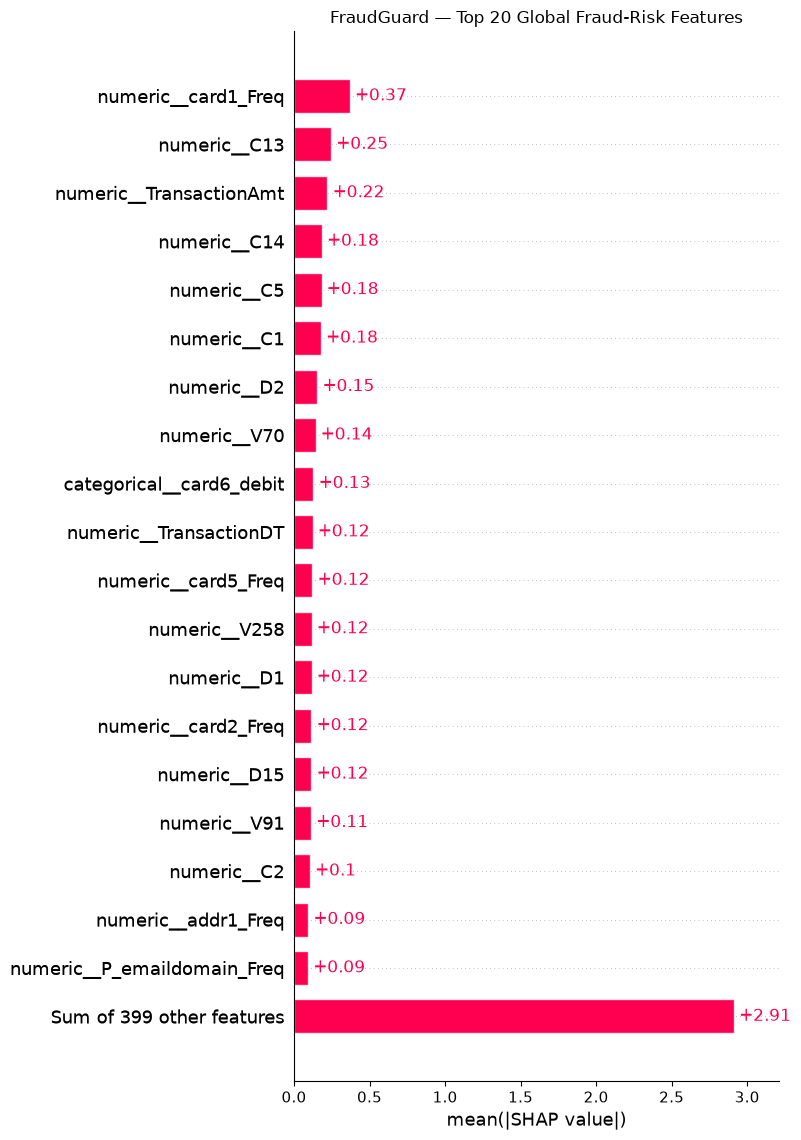

In [113]:
# =================================================
# SHAP EXPLAINABILITY — STEP 4
# Global feature importance
# =================================================

import matplotlib.pyplot as plt


# Attach the correct transformed feature names
shap_values.feature_names = list(shap_feature_names)


print("Creating global SHAP feature importance plot...")


shap.plots.bar(
    shap_values,
    max_display=20,
    show=False
)

plt.title(
    "FraudGuard — Top 20 Global Fraud-Risk Features"
)

plt.tight_layout()
plt.show()

In [114]:
# =================================================
# SHAP STEP 5
# Find a correctly detected high-risk fraud case
# =================================================

sample_probabilities = (
    final_model.predict_proba(X_shap_raw)[:, 1]
)

sample_actual = (
    y_test.iloc[:SHAP_SAMPLE_SIZE]
    .reset_index(drop=True)
)

sample_results = pd.DataFrame({
    "sample_position": np.arange(SHAP_SAMPLE_SIZE),
    "actual_fraud": sample_actual,
    "fraud_probability": sample_probabilities
})

sample_results["predicted_fraud"] = (
    sample_results["fraud_probability"]
    >= final_threshold
).astype(int)


correct_fraud_cases = (
    sample_results[
        (sample_results["actual_fraud"] == 1)
        &
        (sample_results["predicted_fraud"] == 1)
    ]
    .sort_values(
        "fraud_probability",
        ascending=False
    )
)


print("Correctly detected fraud cases:",
      len(correct_fraud_cases))

print("\nTop 10 highest-risk correctly detected frauds:")

display(
    correct_fraud_cases.head(10)
)

Correctly detected fraud cases: 9

Top 10 highest-risk correctly detected frauds:


,sample_position,actual_fraud,fraud_probability,predicted_fraud
111,111,1,0.994370,1
112,112,1,0.991756,1
110,110,1,0.989349,1
109,109,1,0.944856,1
89,89,1,0.816598,1
46,46,1,0.807371,1
93,93,1,0.783730,1
99,99,1,0.761158,1
95,95,1,0.757221,1


FRAUDGUARD — INDIVIDUAL CASE EXPLANATION
-------------------------------------------------------
Sample position: 111
Actual class: Fraud
Fraud probability: 99.44%
Decision threshold: 72.71%

Creating SHAP waterfall plot...


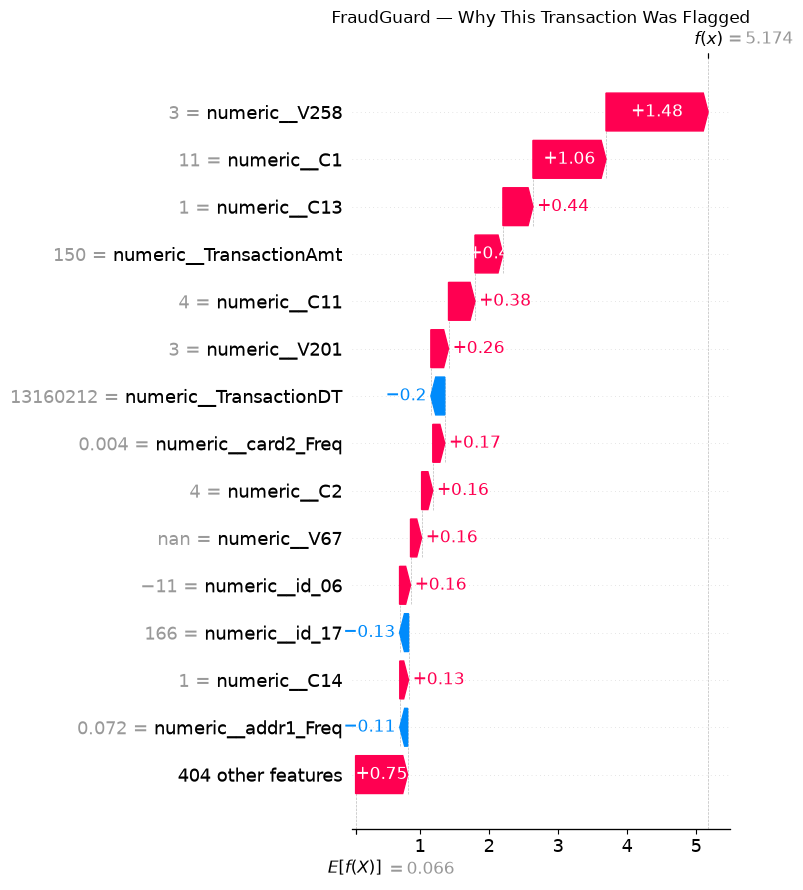

In [115]:
# SHAP STEP 6
# Individual explanation — detected fraud case
example_position = 111

example_explanation = shap.Explanation(
    values=shap_values.values[example_position],
    base_values=shap_values.base_values[example_position],
    data=shap_values.data[example_position],
    feature_names=list(shap_feature_names)
)

print("FRAUDGUARD — INDIVIDUAL CASE EXPLANATION")
print("-" * 55)

print("Sample position:", example_position)

print(
    "Actual class:",
    "Fraud"
    if sample_actual.iloc[example_position] == 1
    else "Legitimate"
)

print(
    f"Fraud probability: "
    f"{sample_probabilities[example_position]:.2%}"
)

print(
    f"Decision threshold: "
    f"{final_threshold:.2%}"
)

print("\nCreating SHAP waterfall plot...")

shap.plots.waterfall(
    example_explanation,
    max_display=15,
    show=False
)

plt.title("FraudGuard — Why This Transaction Was Flagged")

plt.tight_layout()
plt.show()

In [116]:
# SHAP STEP 7
# Extract top risk-increasing and risk-reducing factors

feature_contributions = pd.DataFrame({
    "feature": shap_feature_names,
    "value": shap_values.data[example_position],
    "shap_value": shap_values.values[example_position]
})

risk_increasing = (
    feature_contributions[
        feature_contributions["shap_value"] > 0
    ]
    .sort_values(
        "shap_value",
        ascending=False
    )
    .head(5)
)

risk_reducing = (
    feature_contributions[
        feature_contributions["shap_value"] < 0
    ]
    .sort_values(
        "shap_value",
        ascending=True
    )
    .head(5)
)

print("TOP FACTORS INCREASING FRAUD RISK")
display(risk_increasing)

print("\nTOP FACTORS REDUCING FRAUD RISK")
display(risk_reducing)

TOP FACTORS INCREASING FRAUD RISK


,feature,value,shap_value
253,numeric__V258,3.0,1.479855
3,numeric__C1,11.0,1.058515
15,numeric__C13,1.0,0.435232
1,numeric__TransactionAmt,150.0,0.404684
13,numeric__C11,4.0,0.383439



TOP FACTORS REDUCING FRAUD RISK


,feature,value,shap_value
0,numeric__TransactionDT,1.316021e+07,-0.201727
324,numeric__id_17,1.660000e+02,-0.130169
331,numeric__addr1_Freq,7.191965e-02,-0.114009
349,categorical__card6_debit,1.000000e+00,-0.102970
325,numeric__id_19,2.960000e+02,-0.087073


In [118]:
# SHAP STEP 8
# Reusable explanation function for FraudGuard

def explain_transaction(transaction_row, top_n=5):

    if isinstance(transaction_row, pd.Series):
        transaction_row = transaction_row.to_frame().T

    probability = final_model.predict_proba(
        transaction_row
    )[0, 1]

    transformed_row = trained_preprocessor.transform(
        transaction_row
    )

    explanation = explainer(
        transformed_row
    )

    contributions = pd.DataFrame({
        "feature": shap_feature_names,
        "value": explanation.data[0],
        "shap_value": explanation.values[0]
    })

    increasing = (
        contributions[
            contributions["shap_value"] > 0
        ]
        .sort_values(
            "shap_value",
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )

    reducing = (
        contributions[
            contributions["shap_value"] < 0
        ]
        .sort_values(
            "shap_value",
            ascending=True
        )
        .head(top_n)
        .reset_index(drop=True)
    )

    if probability >= final_threshold:
        decision = "High Fraud Risk"
    else:
        decision = "Below Fraud Alert Threshold"

    return {
        "fraud_probability": float(probability),
        "threshold": float(final_threshold),
        "decision": decision,
        "risk_increasing_factors": increasing,
        "risk_reducing_factors": reducing
    }
    # Test the reusable function on transaction 111

transaction_111 = X_shap_raw.iloc[111]

result_111 = explain_transaction(
    transaction_111
)

print("Decision:", result_111["decision"])

print(
    "Fraud probability:",
    f'{result_111["fraud_probability"]:.2%}'
)

print(
    "Threshold:",
    f'{result_111["threshold"]:.2%}'
)

print("\nTop factors increasing risk:")
display(
    result_111["risk_increasing_factors"]
)

print("\nTop factors reducing risk:")
display(
    result_111["risk_reducing_factors"]
)

Decision: High Fraud Risk
Fraud probability: 99.44%
Threshold: 72.71%

Top factors increasing risk:


,feature,value,shap_value
0,numeric__V258,3.0,1.479855
1,numeric__C1,11.0,1.058515
2,numeric__C13,1.0,0.435232
3,numeric__TransactionAmt,150.0,0.404684
4,numeric__C11,4.0,0.383439



Top factors reducing risk:


,feature,value,shap_value
0,numeric__TransactionDT,13160212,-0.201727
1,numeric__id_17,166.0,-0.130169
2,numeric__addr1_Freq,0.07192,-0.114009
3,categorical__card6_debit,1.0,-0.102970
4,numeric__id_19,296.0,-0.087073


In [119]:
# SHAP STEP 9
# Clean model feature names for analyst display

def clean_feature_name(feature_name):
    feature_name = feature_name.replace(
        "numeric__",
        ""
    )

    feature_name = feature_name.replace(
        "categorical__",
        ""
    )

    return feature_name


def prepare_explanation_for_display(result):

    increasing = (
        result["risk_increasing_factors"]
        .copy()
    )

    reducing = (
        result["risk_reducing_factors"]
        .copy()
    )

    increasing["feature"] = (
        increasing["feature"]
        .apply(clean_feature_name)
    )

    reducing["feature"] = (
        reducing["feature"]
        .apply(clean_feature_name)
    )

    return increasing, reducing


display_increasing, display_reducing = (
    prepare_explanation_for_display(
        result_111
    )
)


print("FRAUDGUARD ANALYST EXPLANATION")

print(
    "\nFraud risk:",
    f'{result_111["fraud_probability"]:.2%}'
)

print(
    "Decision:",
    result_111["decision"]
)

print("\nFactors increasing risk:")
display(display_increasing)

print("\nFactors reducing risk:")
display(display_reducing)

FRAUDGUARD ANALYST EXPLANATION

Fraud risk: 99.44%
Decision: High Fraud Risk

Factors increasing risk:


,feature,value,shap_value
0,V258,3.0,1.479855
1,C1,11.0,1.058515
2,C13,1.0,0.435232
3,TransactionAmt,150.0,0.404684
4,C11,4.0,0.383439



Factors reducing risk:


,feature,value,shap_value
0,TransactionDT,13160212,-0.201727
1,id_17,166.0,-0.130169
2,addr1_Freq,0.07192,-0.114009
3,card6_debit,1.0,-0.102970
4,id_19,296.0,-0.087073


In [120]:
# WEB APP TEST DATA
# Save one real processed test transaction

test_transaction = X_test.iloc[[111]].copy()

test_transaction.to_csv(
    "../outputs/test_transaction_111.csv",
    index=False
)

print("Test transaction saved.")
print("Shape:", test_transaction.shape)

display(
    test_transaction[
        [
            "TransactionDT",
            "TransactionAmt",
            "ProductCD",
            "card4",
            "card6",
            "C1",
            "C13"
        ]
    ]
)

Test transaction saved.
Shape: (1, 359)


,TransactionDT,TransactionAmt,ProductCD,card4,card6,C1,C13
111,13160212,150.0,H,mastercard,debit,11.0,1.0


In [121]:
# WEB APP DEMO TRANSACTIONS
# Find examples across different fraud-risk levels

demo_probabilities = final_model.predict_proba(
    X_test
)[:, 1]

demo_candidates = pd.DataFrame({
    "position": range(len(X_test)),
    "actual_label": y_test.values,
    "fraud_probability": demo_probabilities
})

high_examples = (
    demo_candidates[
        demo_candidates["fraud_probability"] >= final_threshold
    ]
    .sort_values(
        "fraud_probability",
        ascending=False
    )
    .head(5)
)

medium_examples = (
    demo_candidates[
        (demo_candidates["fraud_probability"] >= 0.30)
        &
        (demo_candidates["fraud_probability"] < final_threshold)
    ]
    .sort_values(
        "fraud_probability",
        ascending=False
    )
    .head(5)
)

low_examples = (
    demo_candidates[
        demo_candidates["fraud_probability"] < 0.30
    ]
    .sort_values(
        "fraud_probability",
        ascending=True
    )
    .head(5)
)

print("HIGH-RISK EXAMPLES")
display(high_examples)

print("\nMEDIUM-RISK EXAMPLES")
display(medium_examples)

print("\nLOW-RISK EXAMPLES")
display(low_examples)

HIGH-RISK EXAMPLES


,position,actual_label,fraud_probability
6272,6272,1,0.999745
31681,31681,1,0.999720
5216,5216,1,0.999639
6270,6270,1,0.999632
51474,51474,1,0.999620



MEDIUM-RISK EXAMPLES


,position,actual_label,fraud_probability
2882,2882,0,0.727122
63312,63312,0,0.726870
1282,1282,1,0.726842
62618,62618,0,0.726690
64131,64131,0,0.726365



LOW-RISK EXAMPLES


,position,actual_label,fraud_probability
22172,22172,0,0.000492
19741,19741,0,0.000544
31422,31422,0,0.000575
19737,19737,0,0.000610
526,526,0,0.000622


In [122]:
# WEB APP DEMO TRANSACTIONS
# Save representative high, medium and low-risk examples

demo_positions = {
    "high": 6272,
    "medium": 1282,
    "low": 22172
}

demo_transactions = []

for risk_level, position in demo_positions.items():

    transaction = X_test.iloc[position].copy()

    transaction["DemoRiskLevel"] = risk_level
    transaction["DemoPosition"] = position
    transaction["ActualLabel"] = int(
        y_test.iloc[position]
    )
    transaction["ExpectedProbability"] = float(
        demo_probabilities[position]
    )

    demo_transactions.append(
        transaction
    )


demo_transactions_df = pd.DataFrame(
    demo_transactions
)

demo_transactions_df.to_csv(
    "../outputs/demo_transactions.csv",
    index=False
)

print(
    "Demo transactions saved:",
    demo_transactions_df.shape
)

display(
    demo_transactions_df[
        [
            "DemoRiskLevel",
            "DemoPosition",
            "ActualLabel",
            "ExpectedProbability",
            "TransactionAmt",
            "ProductCD",
            "card4",
            "card6"
        ]
    ]
)

Demo transactions saved: (3, 363)


,DemoRiskLevel,DemoPosition,ActualLabel,ExpectedProbability,TransactionAmt,ProductCD,card4,card6
6272,high,6272,1,0.999745,39.593,C,visa,credit
1282,medium,1282,1,0.726842,35.351,C,visa,credit
22172,low,22172,0,0.000492,178.000,S,visa,credit
